In [14]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("../data/processed/ltv_dataset.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn,LTV
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,Month-to-month,29.85,29.85,No,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,One year,56.95,1889.50,No,1936.30
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Month-to-month,53.85,108.15,Yes,107.70
3,7795-CFOCW,Male,0,No,No,45,No,DSL,One year,42.30,1840.75,No,1903.50
4,9237-HQITU,Female,0,No,No,2,Yes,Fiber optic,Month-to-month,70.70,151.65,Yes,141.40


In [16]:
# Prepare the feature matrix using the same schema as the training data.
# This keeps the categorical columns in the form expected by the loaded model.
model = joblib.load("../models/churn_model.pkl")

X = df.drop(columns=["LTV", "customerID", "Churn"])

cat_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "Contract",
]

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X = X.reindex(columns=model.feature_names_in_, fill_value=0)

X.head()

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,True,False,False,0,0,...,0,0,0,0,False,False,0,0,0,0
1,0,0,34,56.95,1889.50,False,False,True,0,0,...,0,0,0,0,True,False,0,0,0,0
2,0,0,2,53.85,108.15,False,False,True,0,0,...,0,0,0,0,False,False,0,0,0,0
3,0,0,45,42.30,1840.75,False,False,False,0,0,...,0,0,0,0,True,False,0,0,0,0
4,0,0,2,70.70,151.65,False,False,True,0,0,...,0,0,0,0,False,False,0,0,0,0


In [17]:
#Load the Trained Churn Model
model = joblib.load("../models/churn_model.pkl")

print(type(model))
print(model)
print(X.shape)

<class 'sklearn.linear_model._logistic.LogisticRegression'>
LogisticRegression(max_iter=2000, solver='liblinear')
(7032, 30)


In [18]:
#Create the SHAP Explainer for a linear/logistic model.
#Using a prepared feature matrix avoids the API error from the raw dataframe.
explainer = shap.LinearExplainer(model, X)

Background dataset has 7032 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7032 when initializing the masker.


In [19]:
#Generate SHAP Values
#Use a small sample for faster computation.

sample = X.sample(100, random_state=42)

shap_values = explainer(sample)
shap_values.values = np.asarray(shap_values.values, dtype=float)

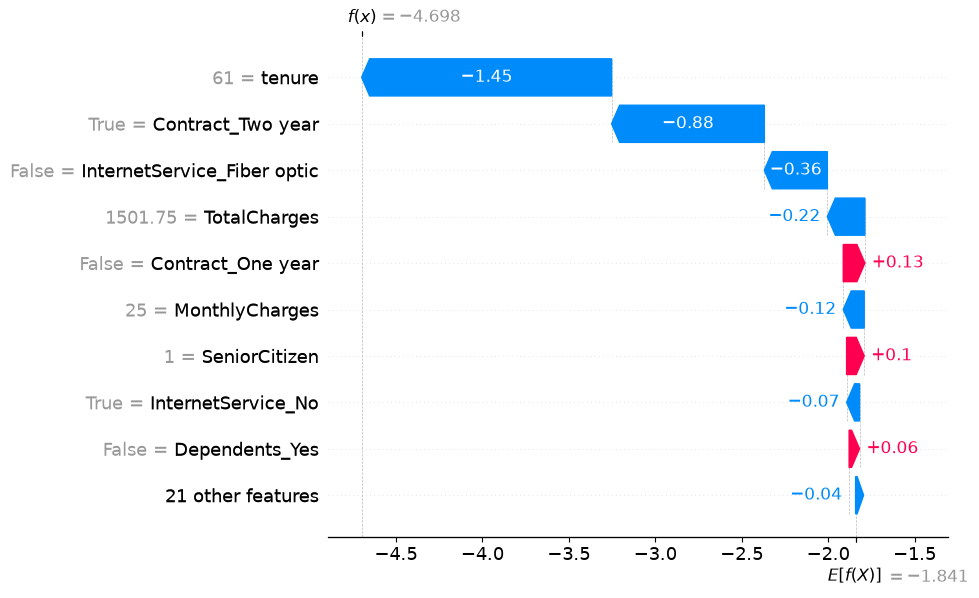

In [20]:
#Create Waterfall Plot for Customer 1
shap.plots.waterfall(shap_values[0])

In [21]:
#Save the Plot
plt.savefig(
    "../docs/images/customer1_waterfall.png",
    bbox_inches="tight"
)

plt.close()

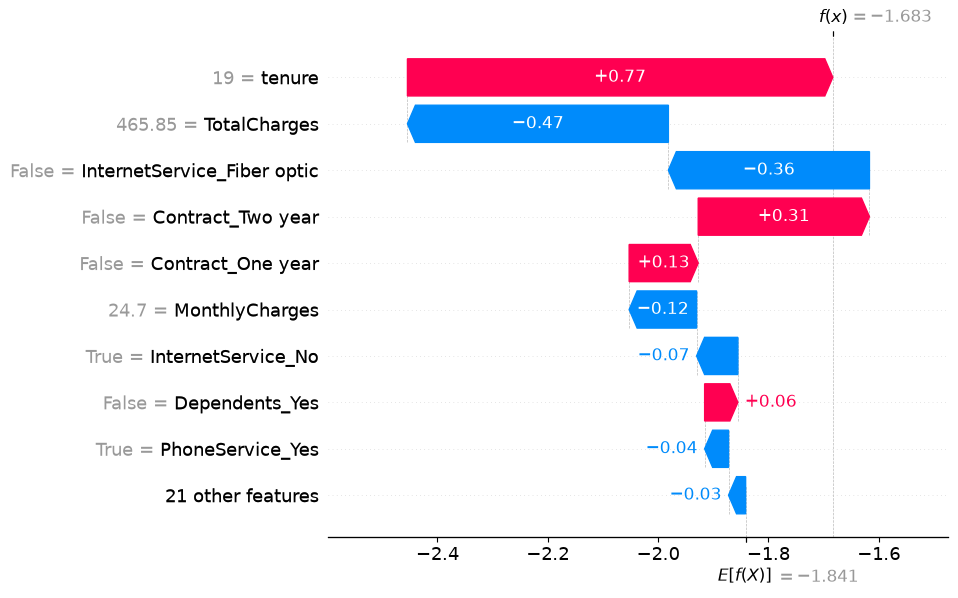

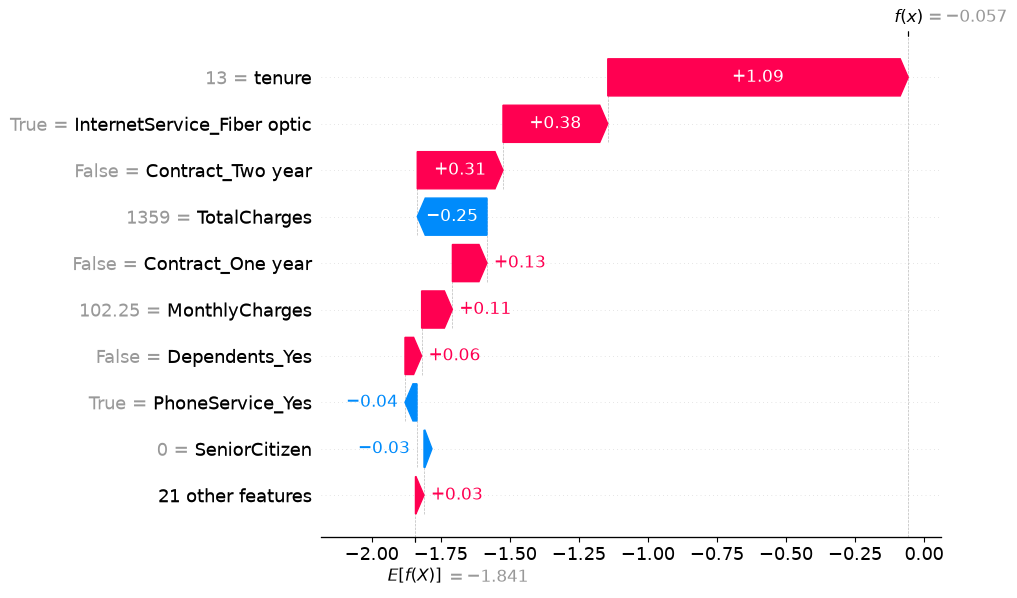

In [22]:
#Create More Customer Examples
#Customer 2:

shap.plots.waterfall(shap_values[1])

plt.savefig(
    "../docs/images/customer2_waterfall.png",
    bbox_inches="tight"
)

plt.close()

#Customer 3:

shap.plots.waterfall(shap_values[2])

plt.savefig(
    "../docs/images/customer3_waterfall.png",
    bbox_inches="tight"
)

plt.close()

In [ ]:
## Customer 1

# Prediction:

# High churn probability

# Main positive contributors:

# - High MonthlyCharges
# - Month-to-month contract
# - Fiber optic internet

# Main negative contributors:

# - Long tenure

# Conclusion:

# The high monthly charges and short-term contract increase churn risk, while long tenure reduces it.